# Cross-split figures

Fig. 2c and Supplementary Fig. S5a: rank-1 energy fraction of the signed residual effects and of the cross-split residual product after removing K = 0–15 leading signed factors. Each panel is written to `figures/` (PDF); the values plotted in both go to one table in `data/` (CSV), with a `panel` column.

The notebook reads the frozen paper results (`results_reference/`) by default. To plot a rerun, run `bash 1_preprocessing/run.sh` and `bash 6_magnitude_structure/run.sh`, then set `USE_REFERENCE=0` (or `USE_REFERENCE = False` below) to read `results/`.

In [1]:
%matplotlib inline
import io
import json
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, "..")  # the repository root, for utils
from utils.paths import CROSS_SPLIT, REPO_ROOT, paper_name, reference

USE_REFERENCE = os.environ.get("USE_REFERENCE", "1") != "0"

PER_DATASET = (reference(CROSS_SPLIT) if USE_REFERENCE else CROSS_SPLIT) / "per_dataset"

FIGURES = REPO_ROOT / "6_magnitude_structure" / "figures"
DATA = REPO_ROOT / "6_magnitude_structure" / "data"
FIGURES.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

DISPLAY_DPI = 110  # inline previews only; the PDFs are vector
MM = 1.0 / 25.4

# Both panels: K = 0-15 factors removed, markers at K = 0, 5, 10, 15, a common 0-65% y-axis.
MARKED_K = [0, 5, 10, 15]
Y_LIMIT = (0.0, 65.0)
Y_TICKS = [0, 20, 40, 60]
SERIES = [  # (column, legend label, color, marker)
    ("mean_split_effect_rank1_percent", "Signed residual effects", "#3F647E", "o"),
    ("mean_signed_product_rank1_percent", "Cross-split residual product", "#D36B4B", "D"),
]


def panel_table(panel, datasets):
    """The rank1_comparison.csv tables of analyze_cross_split_dataset.py, in panel order,
    with the panel, the paper names and the number of split seeds."""
    frames = []
    for order, dataset in enumerate(datasets):
        folder = PER_DATASET / dataset.replace("-", "_")
        n_seeds = json.loads((folder / "run_parameters.json").read_text())["n_split_seeds"]
        frames.append(
            pd.read_csv(folder / "rank1_comparison.csv").assign(
                display_dataset=paper_name(dataset),
                display_order=order,
                n_split_seeds=n_seeds,
                split_seeds=",".join(str(seed) for seed in range(n_seeds)),
            )
        )
    table = pd.concat(frames, ignore_index=True)
    table.insert(0, "panel", panel)
    return table


def show_inline(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=DISPLAY_DPI, facecolor="white")
    display(Image(data=buffer.getvalue()))

## Plotted values

Fig. 2c and S5a: the per-dataset tables `CROSS_SPLIT/per_dataset/<dataset>/rank1_comparison.csv` of `6_magnitude_structure/analyze_cross_split_dataset.py`, in plotting order, with the paper labels.

In [2]:
FIG2C_DATASETS = ["Replogle-E-k562", "Replogle-E-rpe1", "Pan-GW-hESC"]
S5A_DATASETS = [
    "Replogle-GW-k562", "Nadig-HEPG2", "Nadig-JURKAT", "Huang-HCT116", "Huang-HEK293T", "VCC", "Feng-ts",
]
rank1 = pd.concat(
    [panel_table("Fig. 2c", FIG2C_DATASETS), panel_table("Supplementary Fig. S5a", S5A_DATASETS)],
    ignore_index=True,
)
rank1.to_csv(DATA / "cross_split_rank1_energy.csv", index=False)

## Fig. 2c — cross-split rank-1 energy

Replogle-E-K562, Replogle-E-RPE1 and Pan-GP-H1: the `Fig. 2c` rows of the table.

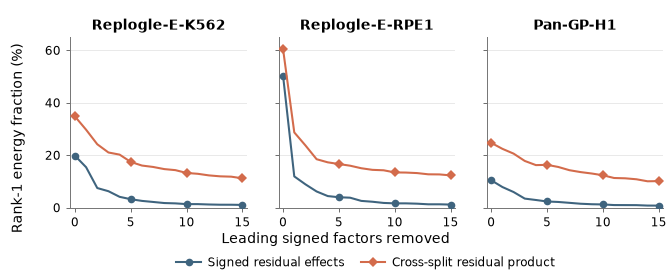

In [3]:
fig2c = rank1[rank1["panel"].eq("Fig. 2c")]

# Start from the matplotlibrc defaults, as the panel script did.
mpl.rc_file_defaults()
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "font.size": 7.8,
        "axes.linewidth": 0.65,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    }
)
figure, axes = plt.subplots(1, 3, figsize=(155.0 * MM, 64.0 * MM), sharex=True, sharey=True)
figure.subplots_adjust(left=0.105, right=0.988, bottom=0.250, top=0.865, wspace=0.18)
for axis, dataset in zip(axes, FIG2C_DATASETS):
    subset = fig2c[fig2c["dataset"] == dataset].sort_values("n_factors_removed")
    for column, _, color, marker in SERIES:
        axis.plot(
            subset["n_factors_removed"].to_numpy(int),
            subset[column].to_numpy(float),
            color=color,
            marker=marker,
            markersize=5.0,
            markeredgewidth=0,
            markevery=MARKED_K,
            linewidth=1.35,
            solid_capstyle="round",
            zorder=3,
        )
    axis.set_title(paper_name(dataset), fontsize=9.2, fontweight="bold", pad=5)
    axis.set_xlim(-0.4, 15.4)
    axis.set_ylim(*Y_LIMIT)
    axis.set_xticks(MARKED_K)
    axis.set_yticks(Y_TICKS)
    axis.grid(axis="y", color="#E5E5E5", linewidth=0.55, zorder=0)
    axis.grid(axis="x", visible=False)
    axis.tick_params(axis="both", labelsize=7.6, width=0.55, length=2.8, color="#555555")
    axis.spines["left"].set_color("#777777")
    axis.spines["bottom"].set_color("#777777")

figure.supxlabel("Leading signed factors removed", fontsize=9.4, y=0.110)
figure.supylabel("Rank-1 energy fraction (%)", fontsize=9.4, x=0.016)
handles = [
    Line2D([0], [0], color=color, marker=marker, markersize=5.0, markeredgewidth=0, linewidth=1.35, label=label)
    for _, label, color, marker in SERIES
]
figure.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.545, 0.010),
    ncol=2,
    fontsize=8.0,
    handlelength=2.0,
    handletextpad=0.55,
    columnspacing=1.35,
    borderaxespad=0,
)
figure.canvas.draw()

show_inline(figure)
figure.savefig(FIGURES / "cross_split_rank1_energy.pdf", facecolor="white")
plt.close(figure)

## Supplementary Fig. S5a — the other seven screens

The Fig. 2c panel for Replogle-GW-K562, Nadig-HepG2, Nadig-Jurkat, Huang-HCT116, Huang-HEK293T, VCC-H1 and Feng-TS-iPSC, from the `Supplementary Fig. S5a` rows of the table.

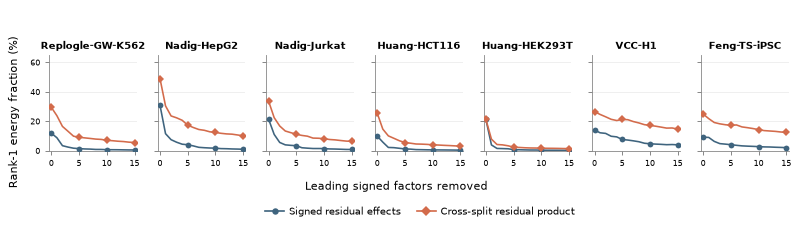

In [4]:
s5a = rank1[rank1["panel"].eq("Supplementary Fig. S5a")]

# Applied on top of the Fig 2c style; it overrides every key of it.
with mpl.rc_context(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "font.size": 6.2,
        "axes.linewidth": 0.55,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    }
):
    figure, axes = plt.subplots(
        1, 7, figsize=(183.0 * MM, 52.0 * MM), sharex=True, sharey=True, squeeze=False
    )
    figure.subplots_adjust(left=0.062, right=0.995, bottom=0.330, top=0.755, wspace=0.24)
    for axis, dataset in zip(axes.flat, S5A_DATASETS):
        subset = s5a[s5a["dataset"] == dataset].sort_values("n_factors_removed")
        for column, _, color, marker in SERIES:
            axis.plot(
                subset["n_factors_removed"].to_numpy(int),
                subset[column].to_numpy(float),
                color=color,
                marker=marker,
                markersize=3.8,
                markeredgewidth=0,
                markevery=MARKED_K,
                linewidth=1.05,
                solid_capstyle="round",
                zorder=3,
            )
        axis.set_ylim(*Y_LIMIT)
        axis.set_yticks(Y_TICKS)
        axis.set_xlim(-0.4, 15.4)
        axis.set_xticks(MARKED_K)
        axis.set_title(paper_name(dataset), fontsize=6.5, fontweight="bold", pad=4)
        axis.grid(axis="y", color="#E8E8E8", linewidth=0.45, zorder=0)
        axis.grid(axis="x", visible=False)
        axis.tick_params(axis="both", labelsize=5.5, width=0.5, length=2.3, color="#666666")
        axis.spines["left"].set_color("#888888")
        axis.spines["bottom"].set_color("#888888")

    figure.supxlabel("Leading signed factors removed", fontsize=7.0, y=0.145)
    figure.supylabel("Rank-1 energy fraction (%)", fontsize=7.0, x=0.010)
    handles = [
        Line2D([0], [0], color=color, marker=marker, markersize=4.2, markeredgewidth=0, linewidth=1.1, label=label)
        for _, label, color, marker in SERIES
    ]
    figure.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.53, 0.018),
        ncol=2,
        fontsize=6.5,
        handlelength=1.9,
        handletextpad=0.5,
        columnspacing=1.6,
        borderaxespad=0,
    )
    figure.canvas.draw()

    figure.savefig(FIGURES / "cross_split_rank1_energy_other_datasets.pdf", facecolor="white")
    show_inline(figure)
    plt.close(figure)